In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 
import statsmodels.api as sm
from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
from matplotlib.colors import LinearSegmentedColormap

In [3]:
# Define paths
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path = '../../hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [4]:
with open('hazel_list.txt', 'r') as file:
    # .strip() removes spaces and \n characters, and we ignore empty lines
    my_gene_list = [line.strip() for line in file if line.strip()]

print(f"Successfully loaded {len(my_gene_list)} genes from hazel_list.txt.")

Successfully loaded 1238 genes from hazel_list.txt.


In [5]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# Aggregate by cluster
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 17)


In [6]:
# Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

mCGN_mc['cluster'] = meta['merged_cluster']
mCGN_cov['cluster'] = meta['merged_cluster']

# Aggregate counts by cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T  # Shape: (genes, clusters)
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
# Aggregate across all genes per cluster
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation (p0) ---
# Gene-wise baseline (pbar)
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# Mask genes with extremely low total coverage to avoid noise
valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m = cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)

# Broadcast expected values: p0 = expit(logit(pbar) + deltas)
# pbar is (genes,), deltas is (clusters,). We create a (genes, clusters) matrix
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Adjusted Matrix ---
# Observed fractions
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

# Residuals: observed deviation from the cluster's global logit expectation
adj_meth_matrix = obs_p - p0_df

# Filter for genes that actually have meaningful methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13764, 17)


In [7]:

# Align genes across modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

# We will use the total coverage (cluster_m) as our weights
final_weights_df = cluster_m.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    # Skip genes with zero variance in either modality
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    # Standardize to make the WLS coefficient behave like a correlation coefficient (Rho)
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    
    # Add constant for intercept
    X = sm.add_constant(meth_z)
    
    try:
        # Fit Weighted Least Squares
        # Endog (Y) = RNA, Exog (X) = Methylation
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        
        # Extract the slope coefficient (pseudo-rho) and its p-value
        # Index 1 is the slope for 'meth_z' (Index 0 is the constant)
        rho = wls_model.params[1] 
        p = wls_model.pvalues[1]
        
        valid_genes.append(gene)
        correlations.append(rho)
        p_values.append(p)
    except Exception:
        # Catch any convergence errors for extremely sparse genes
        continue

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes (WLS, Coverage-Weighted):")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes (WLS, Coverage-Weighted):
                rho   p_value       fdr
gene                                   
AT2G04790 -1.732238  0.000114  0.032653
AT2G07713 -1.663293  0.047919  0.496955
AT1G55370 -1.634012  0.000215  0.045561
AT5G35490 -1.449742  0.000016  0.008352
AT3G29639 -1.407684  0.003538  0.209529
AT2G04825 -1.384154  0.003283  0.206739
AT1G52240 -1.302113  0.001152  0.122335
AT3G21670 -1.298125  0.000027  0.011065
AT3G55735 -1.297038  0.000452  0.069419
AT3G26290 -1.294671  0.000006  0.004282
AT5G49740 -1.251251  0.000018  0.008440
AT2G05615 -1.246359  0.018173  0.376778
AT4G04330 -1.238686  0.014208  0.341467
AT3G29033 -1.235975  0.041621  0.471824
AT4G04265 -1.222466  0.010509  0.302969
AT5G23060 -1.201050  0.020242  0.387271
AT2G07764 -1.197692  0.272472  0.744871
AT5G57760 -1.196886  0.000578  0.081813
AT1G58290 -1.196723  0.000166  0.039083
AT4G38870 -1.191051  0.002114  0.173913


Plotting top 300 genes with the strongest negative WLS correlation, removed Guard and G2M.


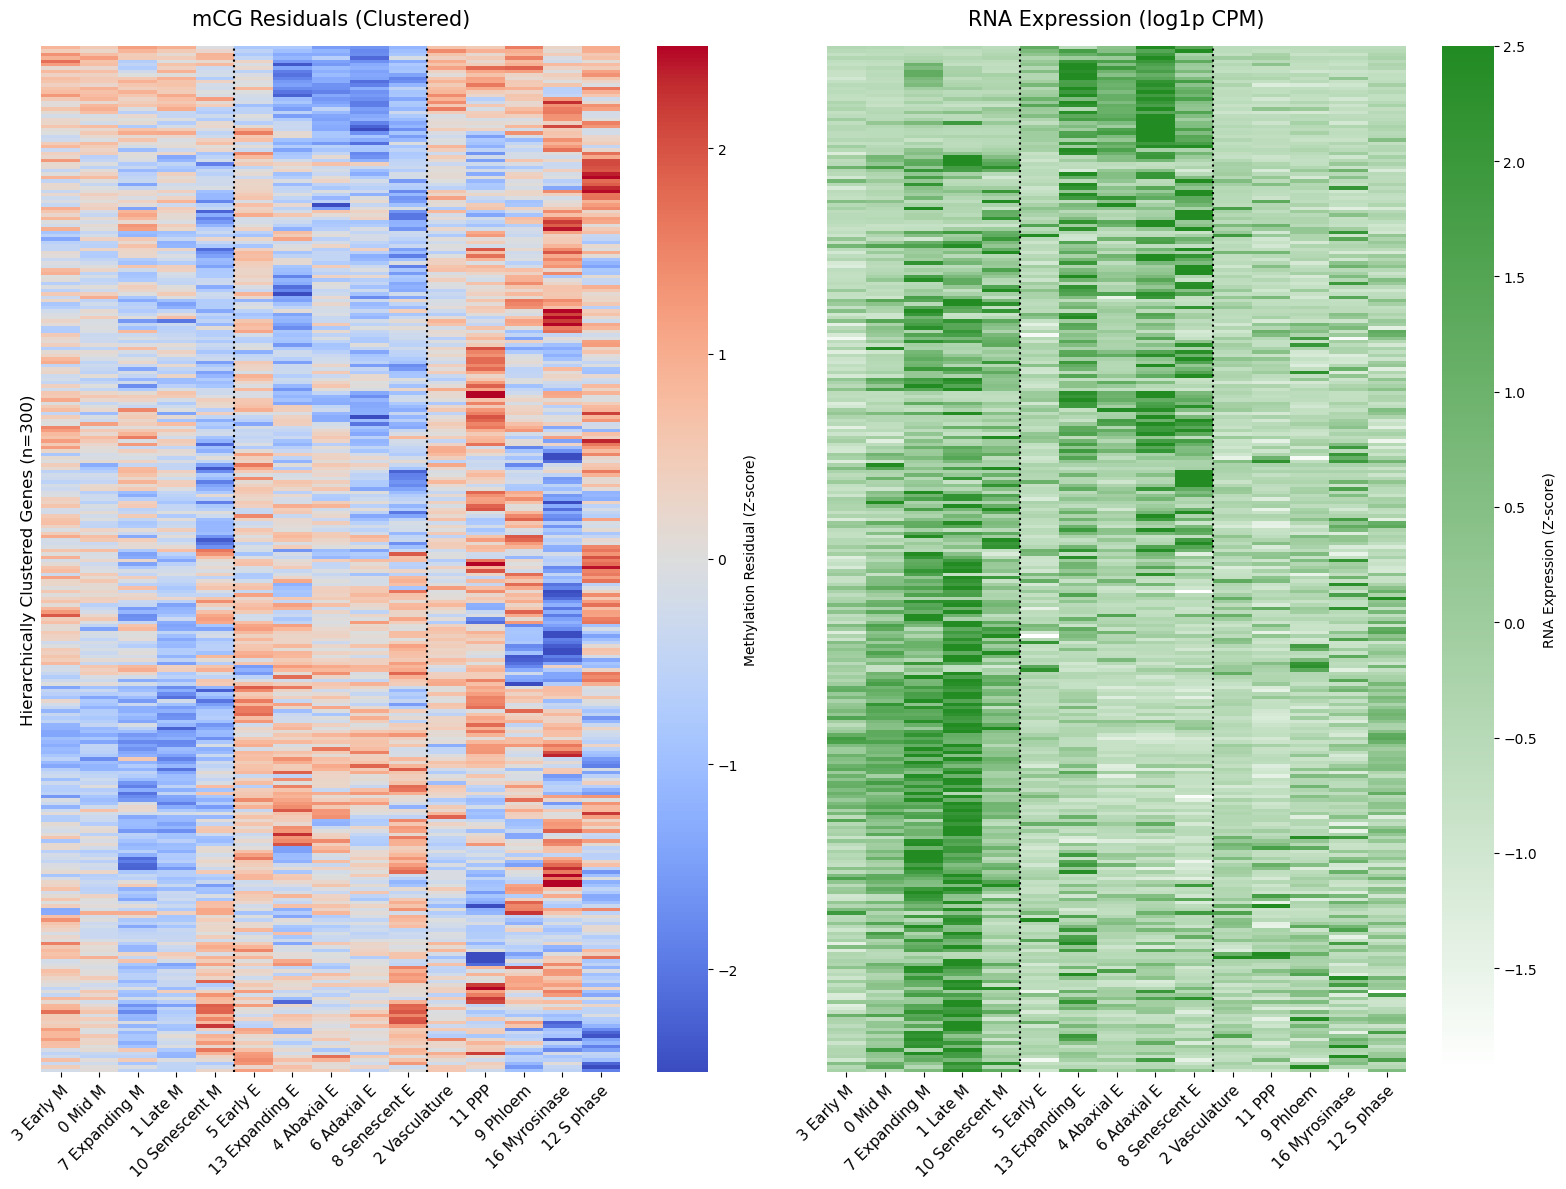

In [12]:
# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]


# 1. Get the Top 300 genes from the WLS results
top_300_genes = stats_df.sort_values('rho').head(300).index
print(f"Plotting top {len(top_300_genes)} genes with the strongest negative WLS correlation, removed Guard and G2M.")

# 2. Data Preparation (Z-scoring)
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(final_meth_df, top_300_genes)
vis_rna_z = prepare_zscore(final_rna_df, top_300_genes)

# 3. Apply Custom Cluster Names and Column Ordering
vis_meth_sorted = vis_meth_z.rename(columns=cluster_mapping)
vis_rna_sorted = vis_rna_z.rename(columns=cluster_mapping)

# Define the exact names of the clusters you want to exclude
clusters_to_drop = ["14 Guard cell", "15 G2M phase"] 

# Filter the valid_order list to exclude the dropped clusters
valid_order = [
    c for c in cluster_order 
    if c in vis_meth_sorted.columns and c not in clusters_to_drop
]

vis_meth_sorted = vis_meth_sorted[valid_order]
vis_rna_sorted = vis_rna_sorted[valid_order]

# --- NEW: 4. Hierarchical Clustering on Genes (Rows) ---
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_sorted.values), method='ward')
row_order = hc.leaves_list(row_linkage)

# Extract the new clustered gene order
clustered_genes = vis_meth_sorted.index[row_order]

# Reorder the rows of both dataframes using this new clustered order
vis_meth_clustered = vis_meth_sorted.loc[clustered_genes]
vis_rna_clustered = vis_rna_sorted.loc[clustered_genes]

# 5. Create custom colormap for RNA (Grey for low, Forest Green for high)
rna_cmap = LinearSegmentedColormap.from_list("Grey_to_Green", ["white", "forestgreen"])

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1]})

# Methylation Heatmap (Coolwarm)
sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1, 
            cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
ax1.set_title("mCG Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_xlabel("")
ax1.set_ylabel(f"Hierarchically Clustered Genes (n={len(top_300_genes)})", fontsize=12)

# --- THE FIX: Anchor the rotated text to the right ---
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax1.tick_params(axis='x', labelsize=11)

# RNA Expression Heatmap (Grey to Green)
sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")

# --- THE FIX: Anchor the rotated text to the right ---
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax2.tick_params(axis='x', labelsize=11)


# Add visual dividers dynamically using partial string matching
divider_positions = []

# Loop through our columns and check if the name contains our target words
for i, col_name in enumerate(valid_order):
    if "Senescent M" in col_name:
        divider_positions.append(i + 1)
    elif "Senescent E" in col_name:
        divider_positions.append(i + 1)

# Draw the lines on both heatmaps
for ax in [ax1, ax2]:
    for pos in divider_positions:
        ax.axvline(pos, color='black', lw=1.5, linestyle=':')

plt.tight_layout()
plt.savefig("./figures/heatmaps/new_rna_meth_wls_top300_clustered_heatmap_filtered_1415.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

Plotting top 300 genes with the strongest negative WLS correlation, removed Guard and G2M.


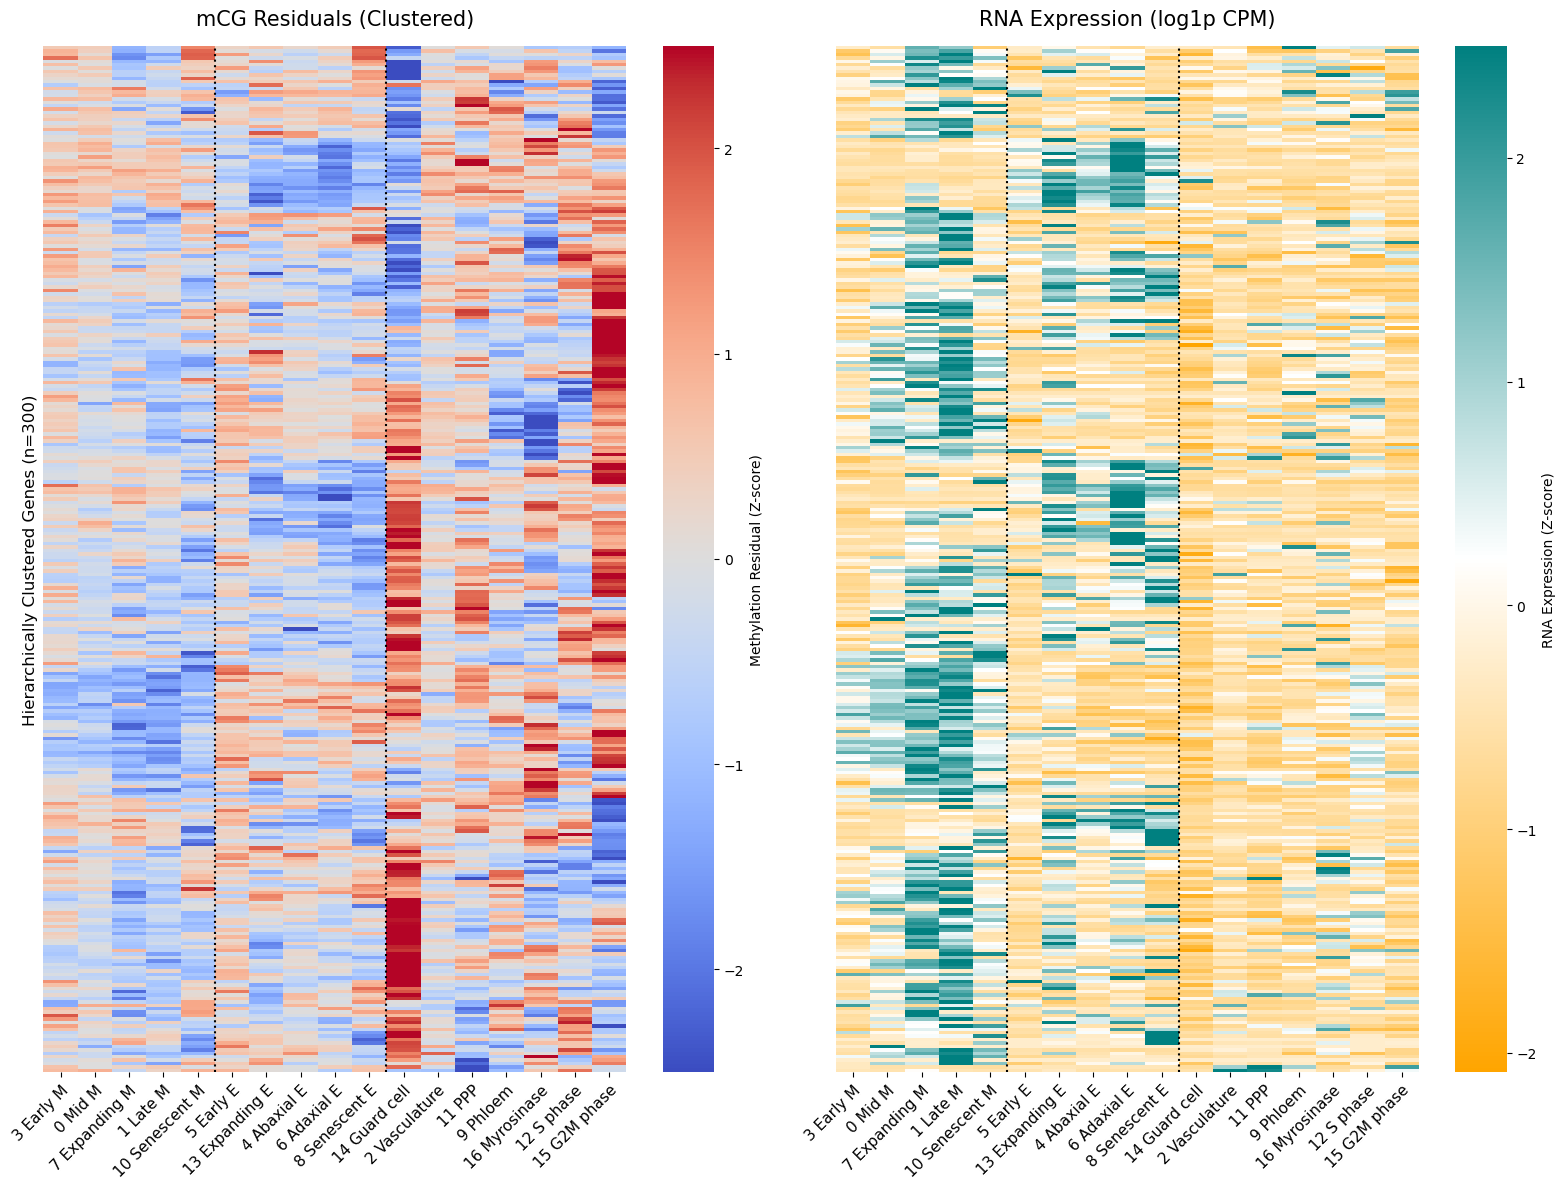

In [14]:
# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]


# 1. Get the Top 300 genes from the WLS results
top_300_genes = stats_df.sort_values('rho').head(300).index
print(f"Plotting top {len(top_300_genes)} genes with the strongest negative WLS correlation, removed Guard and G2M.")

# 2. Data Preparation (Z-scoring)
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(final_meth_df, top_300_genes)
vis_rna_z = prepare_zscore(final_rna_df, top_300_genes)

# 3. Apply Custom Cluster Names and Column Ordering
vis_meth_sorted = vis_meth_z.rename(columns=cluster_mapping)
vis_rna_sorted = vis_rna_z.rename(columns=cluster_mapping)

# Define the exact names of the clusters you want to exclude
clusters_to_drop = [] 

# Filter the valid_order list to exclude the dropped clusters
valid_order = [
    c for c in cluster_order 
    if c in vis_meth_sorted.columns and c not in clusters_to_drop
]

vis_meth_sorted = vis_meth_sorted[valid_order]
vis_rna_sorted = vis_rna_sorted[valid_order]

# --- NEW: 4. Hierarchical Clustering on Genes (Rows) ---
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_sorted.values), method='ward')
row_order = hc.leaves_list(row_linkage)

# Extract the new clustered gene order
clustered_genes = vis_meth_sorted.index[row_order]

# Reorder the rows of both dataframes using this new clustered order
vis_meth_clustered = vis_meth_sorted.loc[clustered_genes]
vis_rna_clustered = vis_rna_sorted.loc[clustered_genes]

# 5. Create custom colormap for RNA (Grey for low, Forest Green for high)
rna_cmap = LinearSegmentedColormap.from_list("Orange_White_Teal", ["orange", "white", "teal"])

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1]})

# Methylation Heatmap (Coolwarm)
sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1, 
            cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
ax1.set_title("mCG Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_xlabel("")
ax1.set_ylabel(f"Hierarchically Clustered Genes (n={len(top_300_genes)})", fontsize=12)

# --- THE FIX: Anchor the rotated text to the right ---
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax1.tick_params(axis='x', labelsize=11)

# RNA Expression Heatmap (Grey to Green)
sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")

# --- THE FIX: Anchor the rotated text to the right ---
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax2.tick_params(axis='x', labelsize=11)


# Add visual dividers dynamically using partial string matching
divider_positions = []

# Loop through our columns and check if the name contains our target words
for i, col_name in enumerate(valid_order):
    if "Senescent M" in col_name:
        divider_positions.append(i + 1)
    elif "Senescent E" in col_name:
        divider_positions.append(i + 1)

# Draw the lines on both heatmaps
for ax in [ax1, ax2]:
    for pos in divider_positions:
        ax.axvline(pos, color='black', lw=1.5, linestyle=':')

plt.tight_layout()
plt.savefig("./figures/heatmaps/new_rna_meth_wls_top300_clustered_heatmap.png", format="png", dpi=300, bbox_inches="tight")
plt.show()